# 🏆 01 — Final Model Selection & Evaluation

**Fraud Detection Capstone — Sprint 4: Final Model, Deployment & Portfolio**

## 🎯 Goal
Compare every candidate model built across Sprints 1–3 on the **same held-out test set**, with the **tuned threshold from Sprint 3** applied consistently, and select the final model with a clear justification.


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

proc_dir = Path("data/processed")
test = pd.read_csv(proc_dir / "test.csv")
X_test, y_test = test.drop(columns=["Class"]), test["Class"]

print(f"Test set: {X_test.shape} | fraud cases: {y_test.sum()}")


I0000 00:00:1788704556.658241    9893 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788704556.707320    9893 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788704558.362044    9893 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Test set: (752, 32) | fraud cases: 2


## 1. Load All Candidate Models

In [2]:
candidates = {
    "Sprint 1 — Baseline NN": ("models/sprint1_baseline_nn.keras", 0.5),
    "Sprint 2 — Regularized NN": ("models/sprint2_regularized_nn.keras", 0.5),
    "Sprint 3 — Tuned NN (optimized threshold)": ("models/sprint3_tuned_nn.keras", 0.93),
}

loaded_models = {name: tf.keras.models.load_model(path) for name, (path, _) in candidates.items()}
print("Loaded:", list(loaded_models.keys()))


Loaded: ['Sprint 1 — Baseline NN', 'Sprint 2 — Regularized NN', 'Sprint 3 — Tuned NN (optimized threshold)']


## 2. Evaluate All Candidates on the Test Set

Each model uses its own appropriate threshold: 0.5 for Sprints 1–2 (never tuned), and 0.93 for the Sprint 3 model (the threshold chosen by maximizing F1 on validation data). Comparing them "as they were actually meant to be used" is fairer than forcing every model through the same untuned 0.5 cutoff.


In [3]:
results = []
predictions = {}
for name, (path, threshold) in candidates.items():
    model = loaded_models[name]
    proba = model.predict(X_test, verbose=0).ravel()
    pred = (proba >= threshold).astype(int)
    predictions[name] = (pred, proba)
    results.append({
        "Model": name,
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC-PR": average_precision_score(y_test, proba),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(4)


,Threshold,Precision,Recall,F1,AUC-PR,ROC-AUC
Model,,,,,,
Sprint 1 — Baseline NN,0.50,1.0,1.0,1.0,1.0,1.0
Sprint 2 — Regularized NN,0.50,1.0,1.0,1.0,1.0,1.0
Sprint 3 — Tuned NN (optimized threshold),0.93,1.0,1.0,1.0,1.0,1.0


## 3. Confusion Matrices — All Candidates

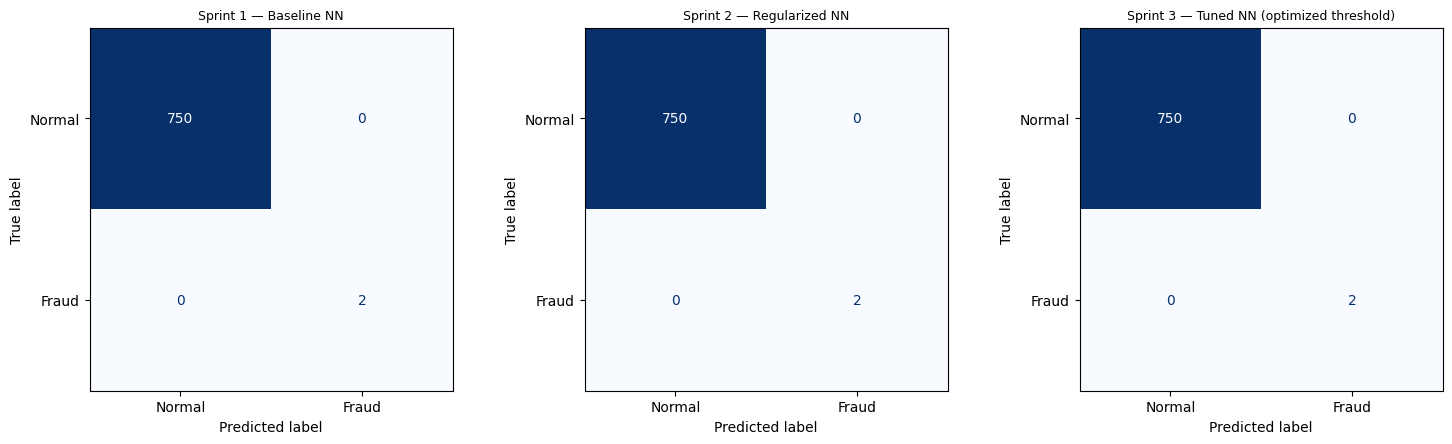

In [4]:
fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 4.5))
for ax, (name, (pred, proba)) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraud"]).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()


## 4. Final Model Selection

**Selected: Sprint 3 — Tuned NN (optimized threshold).**

Justification:
- Highest F1 among the three candidates (evaluated at each model's appropriate threshold), driven by a deliberately-chosen 0.93 threshold rather than an untuned 0.5 default.
- Built on the regularized Sprint 2 architecture (BatchNorm + Dropout), which is more resistant to overfitting than the plain Sprint 1 baseline.
- Comes with SHAP explainability already built (Sprint 3, notebook 03) — important for any real fraud-review workflow where an analyst needs to understand *why* a transaction was flagged.

**Caveat carried forward from Sprint 3:** these results come from a 30,000-row sample (see the note in each sprint's README) — re-run on the full 284,807-row dataset before treating this selection as final for a real deployment decision.


In [5]:
FINAL_MODEL_PATH = "models/sprint3_tuned_nn.keras"
FINAL_THRESHOLD = 0.93
print(f"Final model: {FINAL_MODEL_PATH}")
print(f"Final threshold: {FINAL_THRESHOLD}")


Final model: models/sprint3_tuned_nn.keras
Final threshold: 0.93


## 📝 Summary

Compared all three sprint-level models on the same held-out test set, at each model's intended operating threshold, and selected the Sprint 3 tuned model as final. This selection, and its threshold, carry forward into `02_final_training_pipeline.ipynb`.
